# Audio Classification with CNN and RNN

**Course:** Artificial Neural Networks  
**Task:** Compare CNN vs RNN architectures for speech command classification under varying noise levels.

**Datasets:**
- Google Speech Commands — 1-second spoken word clips (35 classes, 16 kHz)
- ESC-50 — environmental sounds used as background noise

---

## 1. Setup & Imports

In [22]:
%matplotlib inline
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

import os, sys, math, glob
import torch
import torch.nn as nn
import torchaudio
import torchaudio.transforms as T
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
import soundfile as sf
import time

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'
torch.set_num_threads(4)

print(f'PyTorch {torch.__version__}, Torchaudio {torchaudio.__version__}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Additional check for multiple GPUs or specific info
if device.type == 'cuda':
    print(f'GPU Name: {torch.cuda.get_device_name(0)}')
    print(f'Memory Usage: {torch.cuda.memory_allocated(0)/1024**3:.2f} GB')

PyTorch 2.12.0.dev20260304+cu128, Torchaudio 2.11.0.dev20260227+cu128
Using device: cuda
GPU Name: NVIDIA GeForce RTX 5070 Ti
Memory Usage: 0.08 GB


## 2. Data Pipeline

All data loading, noise mixing, and spectrogram caching.

In [23]:
# ═══ Data Pipeline ═══════════════════════════════════════════════════════

# Fix for newer torchaudio versions
def _load_soundfile(filepath, frame_offset=0, num_frames=-1, normalize=True, channels_first=True, format=None):
    data, sample_rate = sf.read(filepath, dtype='float32', always_2d=True)
    data = torch.from_numpy(data.T)
    if frame_offset > 0: data = data[:, frame_offset:]
    if num_frames > 0: data = data[:, :num_frames]
    return data, sample_rate
torchaudio.load = _load_soundfile

# Paths — adjust these if your data is elsewhere
DATA_DIR = '../data'
ESC50_PATH = os.path.join(DATA_DIR, 'ESC-50-master', 'audio')

LABELS = ['backward','bed','bird','cat','dog','down','eight','five',
          'follow','forward','four','go','happy','house','learn','left',
          'marvin','nine','no','off','on','one','right','seven','sheila',
          'six','stop','three','tree','two','up','visual','wow','yes','zero']

# Constants
SAMPLE_RATE = 16000
N_CLASSES   = 35
N_MELS      = 64
N_FFT       = 512
HOP_LENGTH  = 160
CACHE_DIR   = '../results/spec_cache'

class SpeechNoiseDataset(Dataset):
    def __init__(self, speech_ds, noise_dir, noise_level=0.0, sample_rate=16000, transform=None):
        self.speech_ds = speech_ds
        self.noise_level = noise_level
        self.sample_rate = sample_rate
        self.transform = transform
        self.noise_files = glob.glob(os.path.join(noise_dir, '**/*.wav'), recursive=True)
        self.label_to_idx = {label: i for i, label in enumerate(LABELS)}

    def _mix_noise(self, speech_wave, noise_level):
        if noise_level == 0 or not self.noise_files:
            return speech_wave
        noise_idx = np.random.randint(0, len(self.noise_files))
        noise_wave, sr_n = torchaudio.load(self.noise_files[noise_idx])
        if sr_n != self.sample_rate:
            noise_wave = torchaudio.transforms.Resample(sr_n, self.sample_rate)(noise_wave)
        if noise_wave.shape[1] > speech_wave.shape[1]:
            start = np.random.randint(0, noise_wave.shape[1] - speech_wave.shape[1])
            noise_wave = noise_wave[:, start:start + speech_wave.shape[1]]
        else:
            noise_wave = torch.nn.functional.pad(noise_wave, (0, speech_wave.shape[1] - noise_wave.shape[1]))
        speech_rms = torch.sqrt(torch.mean(speech_wave**2))
        noise_rms = torch.sqrt(torch.mean(noise_wave**2))
        if noise_rms > 0:
            factor = (speech_rms / noise_rms) * noise_level
            mixed = speech_wave + noise_wave * factor
            return mixed / (mixed.abs().max() + 1e-7)
        return speech_wave

    def __len__(self): return len(self.speech_ds)

    def __getitem__(self, idx):
        waveform, sr, label_str, _, _ = self.speech_ds[idx]
        if waveform.shape[1] < self.sample_rate:
            waveform = torch.nn.functional.pad(waveform, (0, self.sample_rate - waveform.shape[1]))
        else:
            waveform = waveform[:, :self.sample_rate]
        mixed = self._mix_noise(waveform, self.noise_level)
        if self.transform: mixed = self.transform(mixed)
        return mixed, torch.tensor(self.label_to_idx[label_str])

def get_dataloaders(noise_dir=ESC50_PATH, batch_size=32, noise_level=0.0, transform=None):
    base_ds = torchaudio.datasets.SPEECHCOMMANDS(root=DATA_DIR, download=True)
    total = len(base_ds)
    train_len = int(0.8 * total)
    val_len = int(0.1 * total)
    test_len = total - train_len - val_len
    train_b, val_b, test_b = torch.utils.data.random_split(base_ds, [train_len, val_len, test_len])
    train_loader = DataLoader(SpeechNoiseDataset(train_b, noise_dir, 0, transform=transform),
                              batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(SpeechNoiseDataset(val_b, noise_dir, noise_level, transform=transform),
                            batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(SpeechNoiseDataset(test_b, noise_dir, noise_level, transform=transform),
                             batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader

# Mel Spectrogram transform
mel_transform = nn.Sequential(
    T.MelSpectrogram(sample_rate=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS),
    T.AmplitudeToDB(),
)

def build_cached_loader(loader, split_name, noise_level, batch_size, cache_dir=CACHE_DIR):
    os.makedirs(cache_dir, exist_ok=True)
    cache_path = os.path.join(cache_dir, f'{split_name}_noise{int(noise_level*100):03d}.pt')
    if os.path.exists(cache_path):
        print(f'  Loading cache: {cache_path}')
        data = torch.load(cache_path, weights_only=True)
        specs, labels = data['specs'], data['labels']
    else:
        print(f'  Building cache for {split_name} (noise={int(noise_level*100)}%)... ', end='', flush=True)
        all_s, all_l = [], []
        for s, l in loader: all_s.append(s); all_l.append(l)
        specs, labels = torch.cat(all_s), torch.cat(all_l)
        torch.save({'specs': specs, 'labels': labels}, cache_path)
        print('done.')
    return DataLoader(TensorDataset(specs, labels), batch_size=batch_size,
                      shuffle=(split_name=='train'), num_workers=0)

print(f'ESC-50 files: {len(glob.glob(os.path.join(ESC50_PATH, "**/*.wav"), recursive=True))}')
print('Data pipeline ready.')

ESC-50 files: 2000
Data pipeline ready.


## 3. Dataset Exploration

Total speech samples: 105,829
Sample rate: 16000 Hz, Duration: 1.00s, Label: "backward"
Number of classes: 35


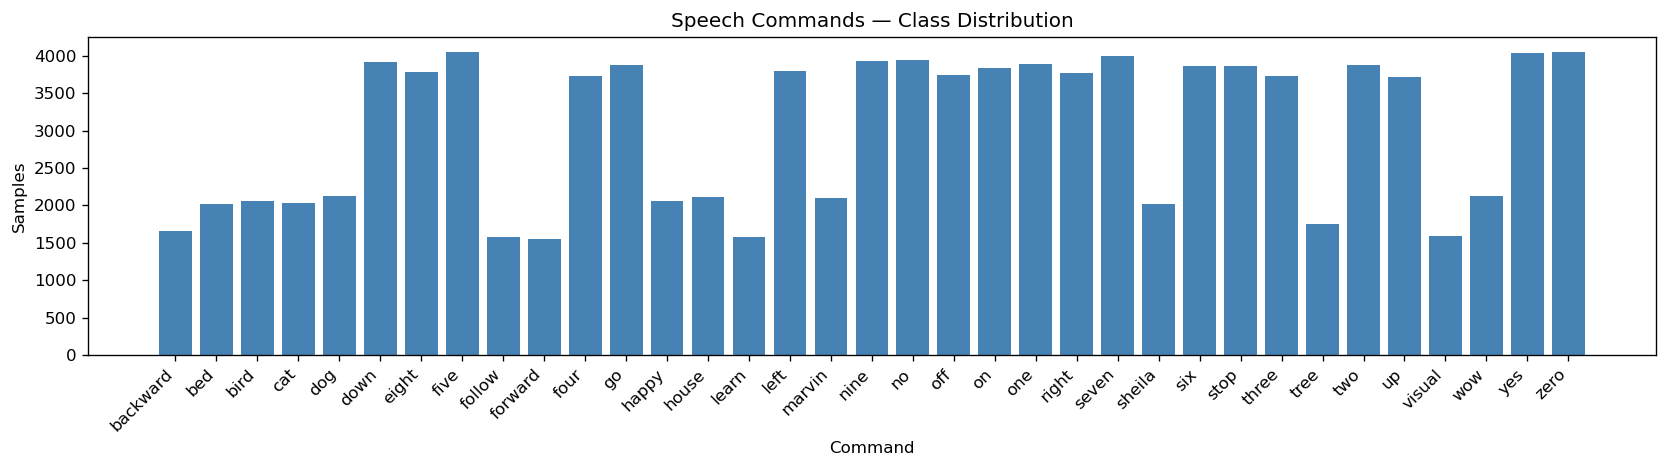

In [3]:
speech_ds = torchaudio.datasets.SPEECHCOMMANDS(root=DATA_DIR, download=False)
print(f'Total speech samples: {len(speech_ds):,}')

waveform, sr, label, *_ = speech_ds[0]
print(f'Sample rate: {sr} Hz, Duration: {waveform.shape[1]/sr:.2f}s, Label: "{label}"')

# Class distribution
all_labels = [speech_ds[i][2] for i in range(len(speech_ds))]
label_counts = Counter(all_labels)
print(f'Number of classes: {len(label_counts)}')

fig, ax = plt.subplots(figsize=(14, 4))
sorted_lbls = sorted(label_counts.keys())
ax.bar(sorted_lbls, [label_counts[l] for l in sorted_lbls], color='steelblue')
ax.set_xlabel('Command'); ax.set_ylabel('Samples')
ax.set_title('Speech Commands — Class Distribution')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

## 4. Noise Mixing Visualization

We mix ESC-50 environmental sounds at 0%, 10%, and 50% of the speech RMS.

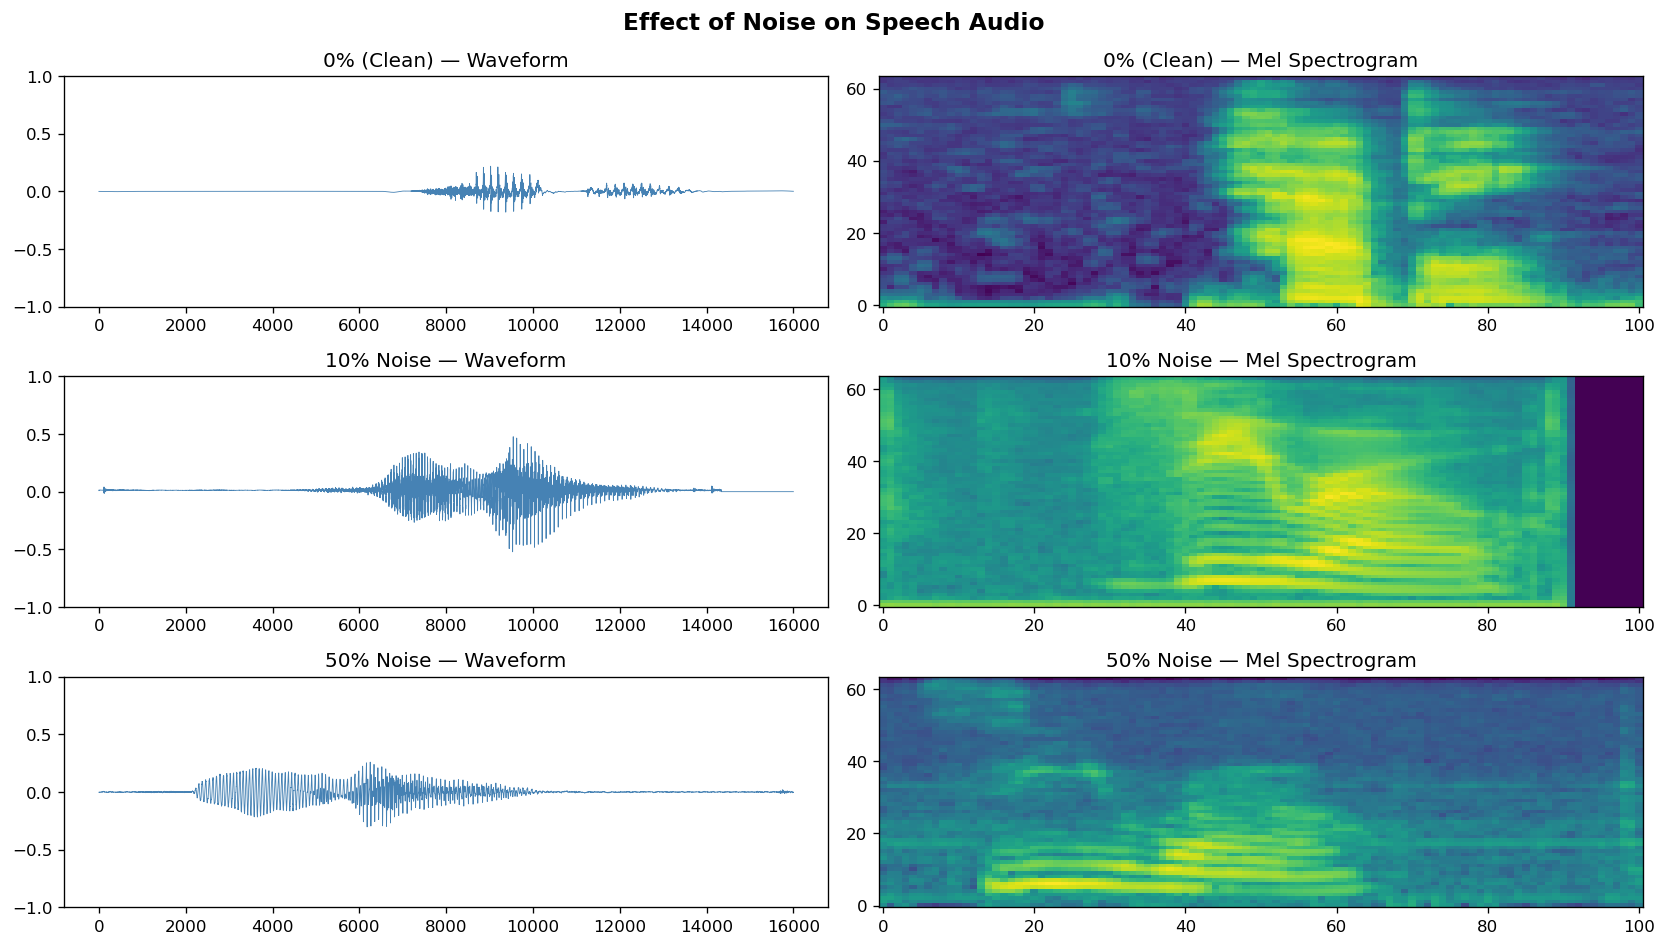

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(14, 8))
for i, (level, name) in enumerate(zip([0.0, 0.1, 0.5], ['0% (Clean)', '10% Noise', '50% Noise'])):
    loader, _, _ = get_dataloaders(noise_level=level, batch_size=1, transform=None)
    wave, _ = next(iter(loader))
    wave = wave.squeeze()
    axes[i,0].plot(wave.numpy(), linewidth=0.5, color='steelblue')
    axes[i,0].set_title(f'{name} — Waveform'); axes[i,0].set_ylim([-1,1])
    spec = mel_transform(wave.unsqueeze(0))
    axes[i,1].imshow(spec.squeeze().numpy(), aspect='auto', origin='lower', cmap='viridis')
    axes[i,1].set_title(f'{name} — Mel Spectrogram')
plt.suptitle('Effect of Noise on Speech Audio', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 5. CNN Model

```
Input [B,1,64,101] → 3 Conv Blocks (32→64→128) → GAP → FC(128→256→35)
```

In [24]:
import torch
import torch.nn as nn

class AudioCNN(nn.Module):
    def __init__(self, n_classes=N_CLASSES):
        super().__init__()
        self.input_norm = nn.BatchNorm2d(1)
        self.features = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.Conv2d(32,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.MaxPool2d(2,2), nn.Dropout2d(0.15),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.MaxPool2d(2,2), nn.Dropout2d(0.2),
            nn.Conv2d(128,300,3,padding=1), nn.BatchNorm2d(300), nn.ReLU(True),
            nn.MaxPool2d(2,2), nn.Dropout2d(0.25),
        )
        self.gap = nn.AdaptiveAvgPool2d((1,1))
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(300,300), nn.ReLU(True), nn.Dropout(0.5), nn.Linear(300,n_classes),
        )

    def forward(self, x):
        x = self.input_norm(x)
        return self.classifier(self.gap(self.features(x)))

cnn_model = AudioCNN().to(device)
cnn_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
dummy_input = torch.randn(2, 1, 64, 101).to(device)
print(f'CNN trainable parameters: {cnn_params:,}')
print(f'Input: [B,1,64,101] → Output: {cnn_model(dummy_input).shape}')

CNN trainable parameters: 549,769
Input: [B,1,64,101] → Output: torch.Size([2, 35])


## 6. RNN Model (Bidirectional GRU)

```
Input [B,1,64,101] → BatchNorm → BiGRU(128) → concat fwd+bwd → FC(256→128→35)
```
GRU chosen over LSTM: fewer parameters, faster training, comparable accuracy on speech.

In [25]:
class AudioRNN(nn.Module):
    def __init__(self, n_classes=N_CLASSES, hidden_size=140, num_layers=2, dropout=0.3):
        super().__init__()
        self.feature_norm = nn.BatchNorm1d(N_MELS)
        self.gru = nn.GRU(input_size=N_MELS, hidden_size=hidden_size, num_layers=num_layers,
                          batch_first=True, bidirectional=True,
                          dropout=dropout if num_layers > 1 else 0.0)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size*2, 128), nn.ReLU(True), nn.Dropout(0.5), nn.Linear(128, n_classes),
        )
    def forward(self, x):
        x = x.squeeze(1)              # [B, 64, 101]
        x = self.feature_norm(x)      # normalize mel features
        x = x.permute(0, 2, 1)        # [B, 101, 64] — time major
        _, h_n = self.gru(x)          # h_n: [2, B, 128]
        h_cat = torch.cat([h_n[-2], h_n[-1]], dim=1)  # [B, 256]
        return self.classifier(h_cat)

rnn_model = AudioRNN().to(device)
rnn_params = sum(p.numel() for p in rnn_model.parameters() if p.requires_grad)
dummy_input = torch.randn(2, 1, 64, 101).to(device)
# Now pass it to the model
print(f'Input: [B,1,64,101] → Output: {cnn_model(dummy_input).shape}')
print(f'RNN trainable parameters: {rnn_params:,}')
print(f'Input: [B,1,64,101] → Output: {rnn_model(dummy_input).shape}')
print(f'\nCNN vs RNN diff: {abs(cnn_params-rnn_params):,} ({abs(cnn_params-rnn_params)/cnn_params*100:.1f}%)')

Input: [B,1,64,101] → Output: torch.Size([2, 35])
RNN trainable parameters: 568,131
Input: [B,1,64,101] → Output: torch.Size([2, 35])

CNN vs RNN diff: 18,362 (3.3%)


## 7. Combined Model (Optional Challenge)

CNN front-end + LSTM back-end

In [26]:
class SmallCombinedModel(nn.Module):
    def __init__(self, vocab_size=N_CLASSES):
        super().__init__()
        # Input: [Batch, 1, 64, 101]
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), 
            nn.BatchNorm2d(32), 
            nn.ReLU(), 
            nn.MaxPool2d(2, 2) 
            # Output here is: [Batch, 32, 32, 50]
        )
        
        # input_size = channels(32) * height(32) = 1024
        self.rnn = nn.LSTM(
            input_size=1024,
            hidden_size=100,
            num_layers=1,
            batch_first=True,
        )   
        self.fc = nn.Linear(100, vocab_size)

    def forward(self, x):
        x = self.cnn(x) # [Batch, 64, 32, 50]
        b, c, h, w = x.size() 
        x = x.permute(0, 3, 1, 2).contiguous()
        x = x.view(b, w, c * h) 
        x, _ = self.rnn(x)
        return self.fc(x[:, -1, :])

# Re-initialize
combined_model = SmallCombinedModel().to(device)
combined_params = sum(p.numel() for p in combined_model.parameters() if p.requires_grad)
print(f'Combined trainable parameters: {combined_params:,}')

Combined trainable parameters: 454,319


## 8. Architecture Comparison

Model              Parameters Type
CNN                   549,769 2D Convolutions
RNN (BiGRU)           568,131 Bidirectional GRU
Combined              454,319 CNN + LSTM


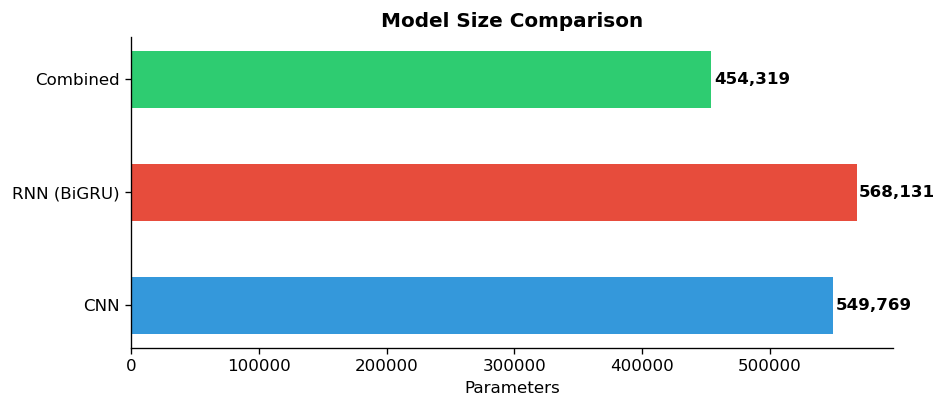

In [61]:
models_info = {
    'CNN': {'params': cnn_params, 'type': '2D Convolutions'},
    'RNN (BiGRU)': {'params': rnn_params, 'type': 'Bidirectional GRU'},
    'Combined': {'params': combined_params, 'type': 'CNN + LSTM'},
}
print(f'{"Model":<16} {"Parameters":>12} {"Type"}')
print('='*50)
for n, info in models_info.items():
    print(f'{n:<16} {info["params"]:>12,} {info["type"]}')

fig, ax = plt.subplots(figsize=(8,3.5))
names = list(models_info.keys()); params = [models_info[n]['params'] for n in names]
bars = ax.barh(names, params, color=['#3498db','#e74c3c','#2ecc71'], height=0.5)
for b, p in zip(bars, params): ax.text(b.get_width()+2000, b.get_y()+b.get_height()/2, f'{p:,}', va='center', fontweight='bold')
ax.set_xlabel('Parameters'); ax.set_title('Model Size Comparison', fontweight='bold')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

## 9. Training

Shared training loop: AdamW + cosine LR with warmup + label smoothing.

In [27]:
@torch.no_grad()
def evaluate_loop(model, loader, criterion):
    model.eval()
    loss, correct, total = 0.0, 0, 0
    for s, l in loader:
        # Move data to GPU
        s, l = s.to(device), l.to(device) 
        
        out = model(s)
        ls = criterion(out, l)
        
        loss += ls.item() * l.size(0)
        correct += (out.argmax(1) == l).sum().item()
        total += l.size(0)
    return loss / total, correct / total

def train_model(model, train_loader, val_loader, epochs=30, lr=1e-3, clip_grad=None):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    
    warmup = 3
    def lr_lambda(ep):
        if ep < warmup: return (ep + 1) / warmup
        return 0.5 * (1 + math.cos(math.pi * (ep - warmup) / max(1, epochs - warmup)))
    
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val, best_w = float('inf'), None
    
    for ep in range(1, epochs + 1):
        model.train()
        tl, tc, tt = 0.0, 0, 0
        
        for s, l in train_loader:
            # Move data to GPU
            s, l = s.to(device), l.to(device)
            
            optimizer.zero_grad(set_to_none=True)
            out = model(s)
            loss = criterion(out, l)
            loss.backward()
            
            if clip_grad: 
                torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
                
            optimizer.step()
            
            tl += loss.item() * l.size(0)
            tc += (out.argmax(1) == l).sum().item()
            tt += l.size(0)
            
        # Proper division for epoch metrics
        current_train_loss = tl / tt
        current_train_acc = tc / tt

        vl, va = evaluate_loop(model, val_loader, criterion)
        
        history['train_loss'].append(current_train_loss)
        history['train_acc'].append(current_train_acc)
        history['val_loss'].append(vl)
        history['val_acc'].append(va)
        
        if vl < best_val:
            best_val = vl
            best_w = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            
        print(f'  Epoch {ep:2d}/{epochs} | Train {current_train_acc:.3f} | Val {va:.3f} | LR {scheduler.get_last_lr()[0]:.5f}')
        
        scheduler.step()

    if best_w: 
        model.load_state_dict(best_w)
        
    print(f'  Best val loss: {best_val:.4f}')
    return model, history

## 10. Train / Load Models

In [ ]:
RESULTS = '../results'
os.makedirs(RESULTS, exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Additional check for multiple GPUs or specific info
if device.type == 'cuda':
    print(f'GPU Name: {torch.cuda.get_device_name(0)}')
    print(f'Memory Usage: {torch.cuda.memory_allocated(0)/1024**3:.2f} GB')

# ── CNN ──
cnn_path = f'{RESULTS}/cnn_model.pth'
if os.path.exists(cnn_path):
    print('Loading CNN...'); cnn_model.load_state_dict(torch.load(cnn_path, weights_only=True))
    cnn_model.eval(); cnn_history = None; print('Done.')
else:
    print('Training CNN...')
    tr,va,_ = get_dataloaders(noise_level=0.0, batch_size=32, transform=mel_transform)
    ct = build_cached_loader(tr,'full_train',0.0,128); cv = build_cached_loader(va,'full_val',0.0,128)
    start_time_cnn = time.time()
    cnn_model, cnn_history = train_model(cnn_model, ct, cv, epochs=50, clip_grad=5.0)
    end_time_cnn = time.time()
    torch.save(cnn_model.state_dict(), cnn_path)

# ── RNN ──
rnn_path = f'{RESULTS}/rnn_model.pth'
if os.path.exists(rnn_path):
    print('Loading RNN...'); rnn_model.load_state_dict(torch.load(rnn_path, weights_only=True))
    rnn_model.eval(); rnn_history = None; print('Done.')
else:
    print('Training RNN...')
    tr,va,_ = get_dataloaders(noise_level=0.0, batch_size=32, transform=mel_transform)
    ct = build_cached_loader(tr,'full_train',0.0,128); cv = build_cached_loader(va,'full_val',0.0,128)
    start_time_rnn = time.time()
    rnn_model, rnn_history = train_model(rnn_model, ct, cv, epochs=50, clip_grad=5.0)
    end_time_rnn = time.time()
    torch.save(rnn_model.state_dict(), rnn_path)

# ── Combined ──
comb_path = f'{RESULTS}/combined_model.pth'
if os.path.exists(comb_path):
    print('Loading Combined...'); combined_model.load_state_dict(torch.load(comb_path, weights_only=True))
    combined_model.eval(); combined_history = None; print('Done.')
else:
    print('Training Combined...')
    tr,va,_ = get_dataloaders(noise_level=0.0, batch_size=32, transform=mel_transform)
    ct = build_cached_loader(tr,'full_train',0.0,128); cv = build_cached_loader(va,'full_val',0.0,128)
    start_time_combined = time.time()
    combined_model, combined_history = train_model(combined_model, ct, cv, epochs=50, clip_grad=5.0)
    end_time_combined = time.time()
    torch.save(combined_model.state_dict(), comb_path)

print('Elapsed CNN training time: ', end_time_cnn-start_time_cnn)
print('Elapsed RNN training time: ', end_time_rnn-start_time_rnn)
print('Elapsed combined training time: ', end_time_combined-start_time_combined)

Using device: cuda
GPU Name: NVIDIA GeForce RTX 5070 Ti
Memory Usage: 0.09 GB
Training CNN...
  Loading cache: ../results/spec_cache\full_train_noise000.pt
  Loading cache: ../results/spec_cache\full_val_noise000.pt
  Epoch  1/50 | Train 0.125 | Val 0.298 | LR 0.00033
  Epoch  2/50 | Train 0.365 | Val 0.606 | LR 0.00067
  Epoch  3/50 | Train 0.598 | Val 0.738 | LR 0.00100
  Epoch  4/50 | Train 0.733 | Val 0.840 | LR 0.00100
  Epoch  5/50 | Train 0.790 | Val 0.882 | LR 0.00100
  Epoch  6/50 | Train 0.822 | Val 0.901 | LR 0.00100
  Epoch  7/50 | Train 0.845 | Val 0.905 | LR 0.00099
  Epoch  8/50 | Train 0.861 | Val 0.912 | LR 0.00098
  Epoch  9/50 | Train 0.873 | Val 0.930 | LR 0.00097
  Epoch 10/50 | Train 0.882 | Val 0.931 | LR 0.00096
  Epoch 11/50 | Train 0.892 | Val 0.932 | LR 0.00095
  Epoch 12/50 | Train 0.898 | Val 0.934 | LR 0.00093
  Epoch 13/50 | Train 0.903 | Val 0.940 | LR 0.00091
  Epoch 14/50 | Train 0.908 | Val 0.938 | LR 0.00089
  Epoch 15/50 | Train 0.913 | Val 0.941 | 

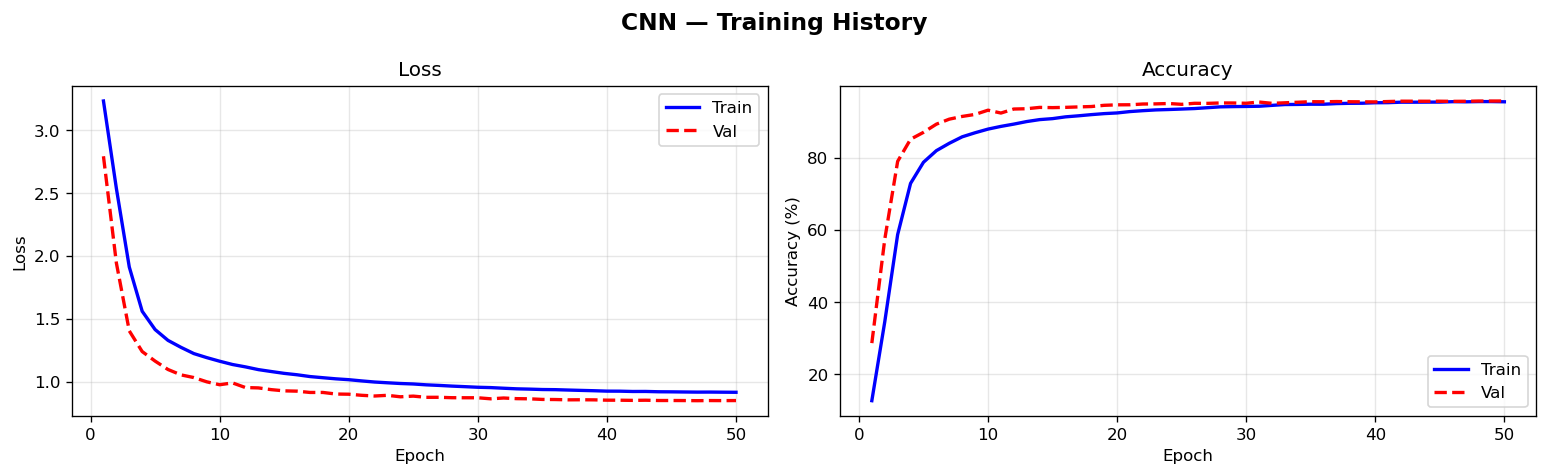

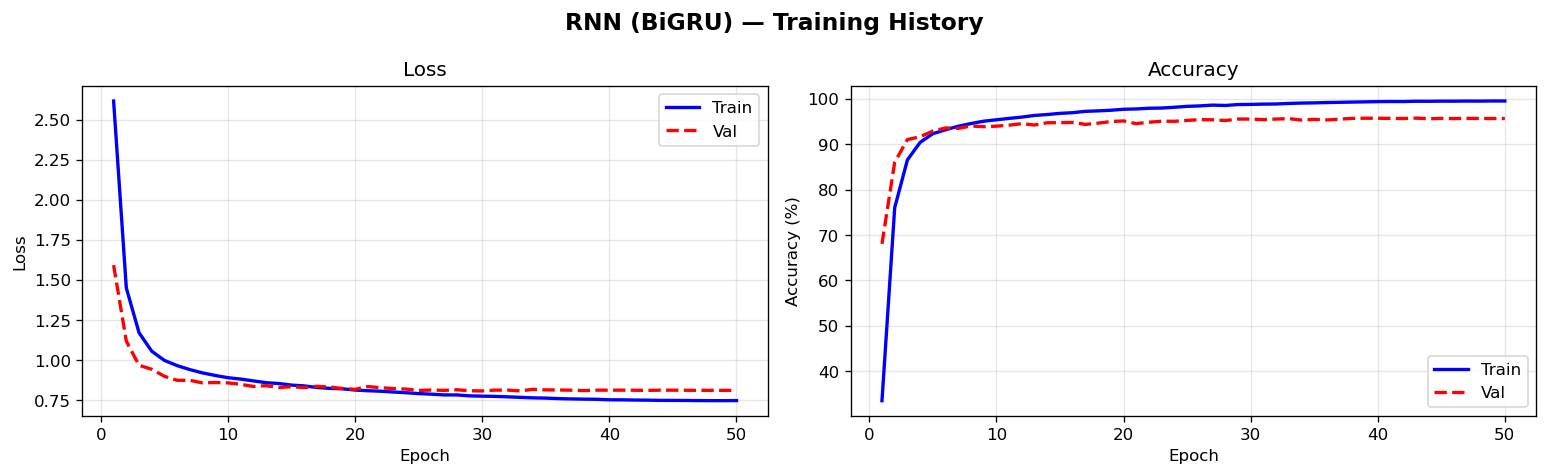

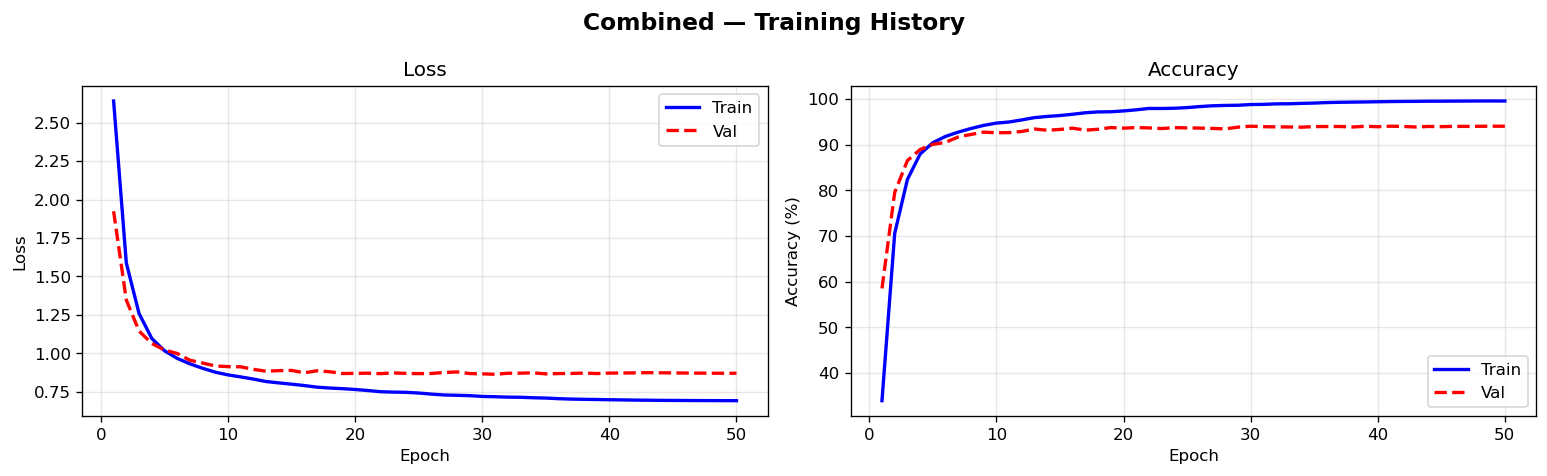

In [64]:
# Show training curves if available
for name, hist in [('CNN', cnn_history), ('RNN (BiGRU)', rnn_history), ('Combined', combined_history)]:
    if hist is None:
        print(f'{name}: loaded from checkpoint (no training history)')
        continue
    epochs = range(1, len(hist['train_loss'])+1)
    fig, (a1,a2) = plt.subplots(1,2,figsize=(13,4))
    fig.suptitle(f'{name} — Training History', fontsize=14, fontweight='bold')
    a1.plot(epochs, hist['train_loss'],'b-',lw=2,label='Train'); a1.plot(epochs, hist['val_loss'],'r--',lw=2,label='Val')
    a1.set_xlabel('Epoch'); a1.set_ylabel('Loss'); a1.set_title('Loss'); a1.legend(); a1.grid(alpha=0.3)
    a2.plot(epochs,[a*100 for a in hist['train_acc']],'b-',lw=2,label='Train')
    a2.plot(epochs,[a*100 for a in hist['val_acc']],'r--',lw=2,label='Val')
    a2.set_xlabel('Epoch'); a2.set_ylabel('Accuracy (%)'); a2.set_title('Accuracy'); a2.legend(); a2.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

## 11. Evaluation at 0%, 10%, 50% Noise

All models trained on clean data — now we test robustness to noise.

In [65]:
noise_levels = [0.0, 0.1, 0.5]
criterion = nn.CrossEntropyLoss()
all_results = {}
models_to_test = {'CNN': cnn_model, 'RNN (BiGRU)': rnn_model, 'Combined': combined_model}

for mname, model in models_to_test.items():
    model.eval()
    all_results[mname] = {}
    print(f'\n{"="*55}\n  {mname}\n{"="*55}')
    
    for nl in noise_levels:
        # Load test data
        _, _, tl = get_dataloaders(noise_level=nl, batch_size=32, transform=mel_transform)
        ct = build_cached_loader(tl, 'full_test', nl, 128)
        
        preds, trues, tloss, tot = [], [], 0.0, 0
        
        with torch.no_grad():
            for s, l in ct:
                # 1. Move inputs/labels to GPU
                s, l = s.to(device), l.to(device)
                
                # 2. Forward pass
                out = model(s)
                ls = criterion(out, l)
                
                # 3. Accumulate loss
                tloss += ls.item() * l.size(0)
                tot += l.size(0)
                
                # 4. Move predictions and labels back to CPU for NumPy/Sklearn
                # .cpu() is required before .numpy() if the tensor is on GPU
                preds.append(out.argmax(1).cpu().numpy())
                trues.append(l.cpu().numpy())
        
        # Concatenate results
        yt, yp = np.concatenate(trues), np.concatenate(preds)
        
        # Calculate metrics
        acc = accuracy_score(yt, yp)
        f1 = f1_score(yt, yp, average='macro', zero_division=0)
        
        # Store results
        all_results[mname][nl] = {
            'accuracy': acc, 
            'f1_macro': f1, 
            'loss': tloss / tot, 
            'y_true': yt, 
            'y_pred': yp
        }
        
        print(f'  {int(nl*100):>2}% noise → Acc: {acc*100:5.1f}%, F1: {f1:.4f}, Loss: {tloss/tot:.4f}')


  CNN
  Loading cache: ../results/spec_cache\full_test_noise000.pt
   0% noise → Acc:  97.7%, F1: 0.9739, Loss: 0.1866
  Loading cache: ../results/spec_cache\full_test_noise010.pt
  10% noise → Acc:  95.4%, F1: 0.9516, Loss: 0.2891
  Loading cache: ../results/spec_cache\full_test_noise050.pt
  50% noise → Acc:  87.3%, F1: 0.8657, Loss: 0.6246

  RNN (BiGRU)
  Loading cache: ../results/spec_cache\full_test_noise000.pt
   0% noise → Acc:  98.6%, F1: 0.9851, Loss: 0.1344
  Loading cache: ../results/spec_cache\full_test_noise010.pt
  10% noise → Acc:  93.2%, F1: 0.9284, Loss: 0.3401
  Loading cache: ../results/spec_cache\full_test_noise050.pt
  50% noise → Acc:  80.8%, F1: 0.7971, Loss: 0.8123

  Combined
  Loading cache: ../results/spec_cache\full_test_noise000.pt
   0% noise → Acc:  97.8%, F1: 0.9762, Loss: 0.1892
  Loading cache: ../results/spec_cache\full_test_noise010.pt
  10% noise → Acc:  91.0%, F1: 0.9052, Loss: 0.4497
  Loading cache: ../results/spec_cache\full_test_noise050.pt
 

## 12. Results Summary

In [75]:
print(f'{"Model":<16} {"0%":>8} {"10%":>8} {"50%":>8} {"Params":>10}')
print('='*55)
for mn in all_results:
    a = [all_results[mn][nl]['accuracy']*100 for nl in noise_levels]
    print(f'{mn:<16} {a[0]:>6.1f}% {a[1]:>6.1f}% {a[2]:>6.1f}% {models_info[mn]["params"]:>10,}')
print(f'\nMinimum required: 75% on clean data')
for mn in all_results:
    a = all_results[mn][0.0]['accuracy']
    print(f'  {mn}: {a*100:.1f}% — {"PASS" if a>=0.75 else "FAIL"}')

Model                  0%      10%      50%     Params
CNN                97.7%   95.4%   87.3%    549,769
RNN (BiGRU)        98.6%   93.2%   80.8%    568,131
Combined           97.8%   91.0%   72.3%    454,319

Minimum required: 75% on clean data
  CNN: 97.7% — PASS
  RNN (BiGRU): 98.6% — PASS
  Combined: 97.8% — PASS


## 13. Performance Comparison Plots

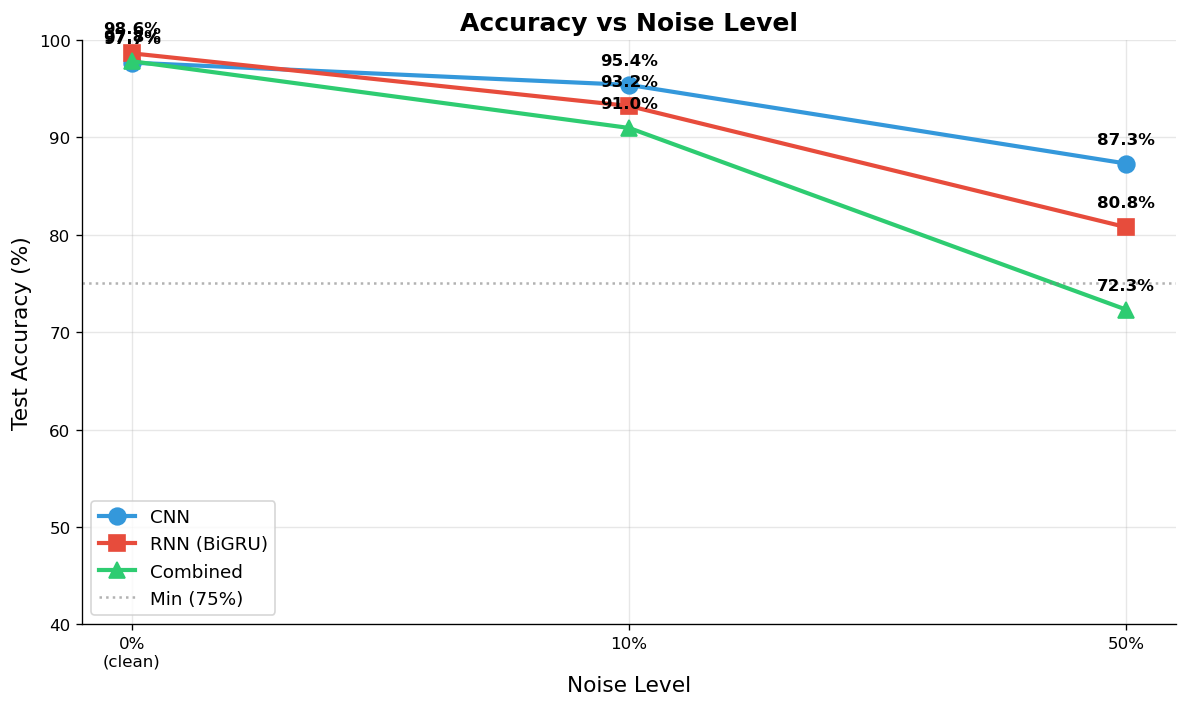

In [67]:
colors = {'CNN':'#3498db', 'RNN (BiGRU)':'#e74c3c', 'Combined':'#2ecc71'}
markers = {'CNN':'o', 'RNN (BiGRU)':'s', 'Combined':'^'}
xlbl = ['0%\n(clean)', '10%', '50%']

fig, ax = plt.subplots(figsize=(10,6))
for mn, res in all_results.items():
    accs = [res[nl]['accuracy']*100 for nl in noise_levels]
    ax.plot(xlbl, accs, marker=markers[mn], ms=10, lw=2.5, label=mn, color=colors[mn])
    for i, a in enumerate(accs): ax.annotate(f'{a:.1f}%',(xlbl[i],a), textcoords='offset points',xytext=(0,12),ha='center',fontweight='bold')
ax.axhline(y=75, color='gray', ls=':', alpha=0.6, label='Min (75%)')
ax.set_xlabel('Noise Level',fontsize=13); ax.set_ylabel('Test Accuracy (%)',fontsize=13)
ax.set_title('Accuracy vs Noise Level',fontsize=15,fontweight='bold')
ax.legend(fontsize=11,loc='lower left'); ax.set_ylim([40,100]); ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

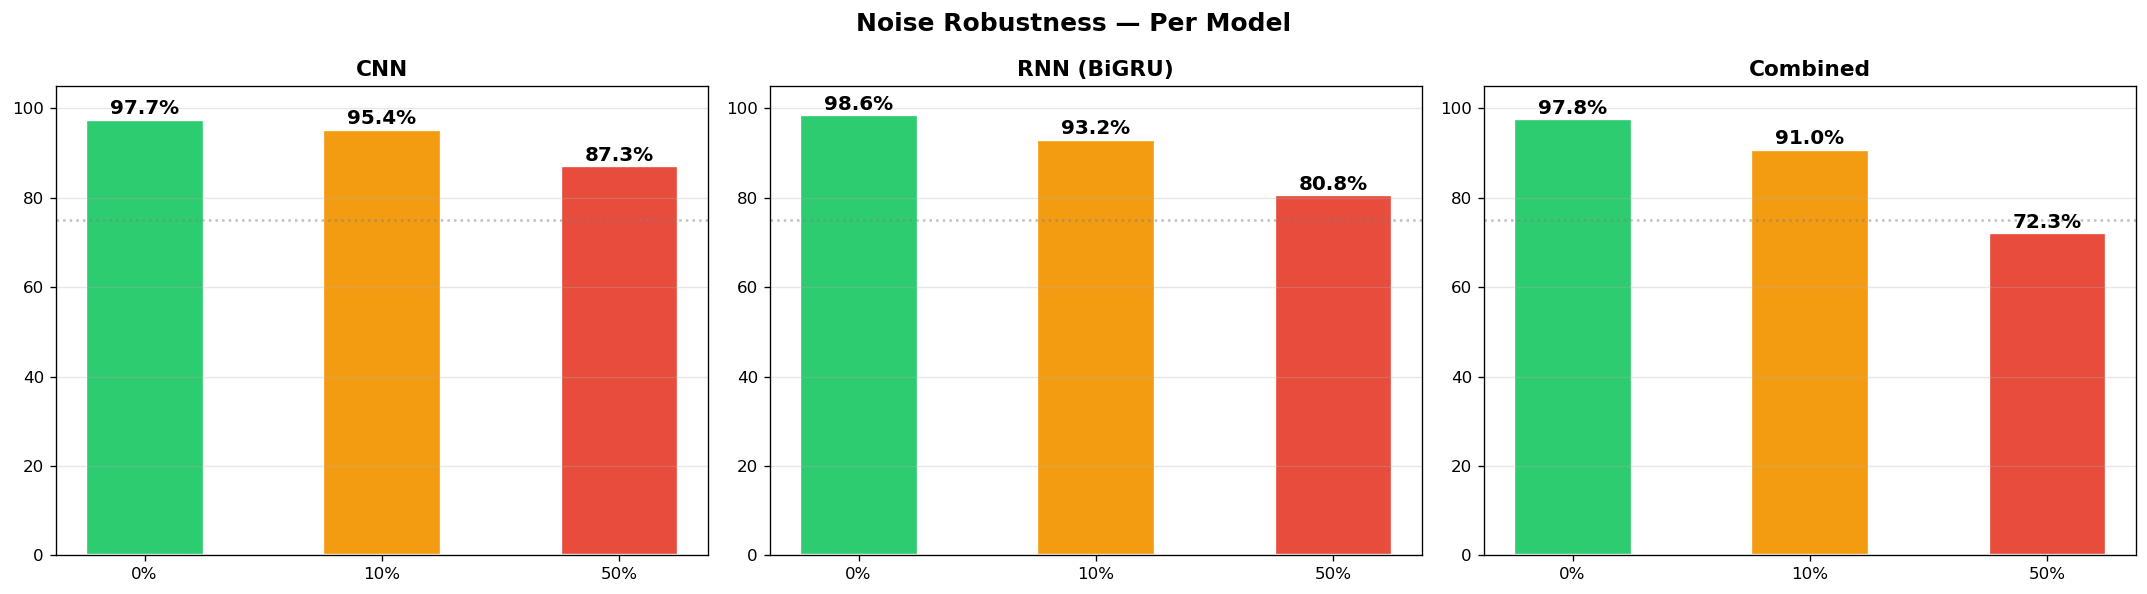

In [68]:
fig, axes = plt.subplots(1,3,figsize=(18,5))
bc = ['#2ecc71','#f39c12','#e74c3c']
for i,(mn,res) in enumerate(all_results.items()):
    accs = [res[nl]['accuracy']*100 for nl in noise_levels]
    bars = axes[i].bar(['0%','10%','50%'], accs, color=bc, width=0.5, edgecolor='white', lw=2)
    for b,a in zip(bars,accs): axes[i].text(b.get_x()+b.get_width()/2, b.get_height()+1, f'{a:.1f}%', ha='center', fontsize=12, fontweight='bold')
    axes[i].set_title(mn, fontsize=13, fontweight='bold'); axes[i].set_ylim([0,105])
    axes[i].axhline(y=75,color='gray',ls=':',alpha=0.5); axes[i].grid(axis='y',alpha=0.3)
plt.suptitle('Noise Robustness — Per Model',fontsize=15,fontweight='bold')
plt.tight_layout(); plt.show()

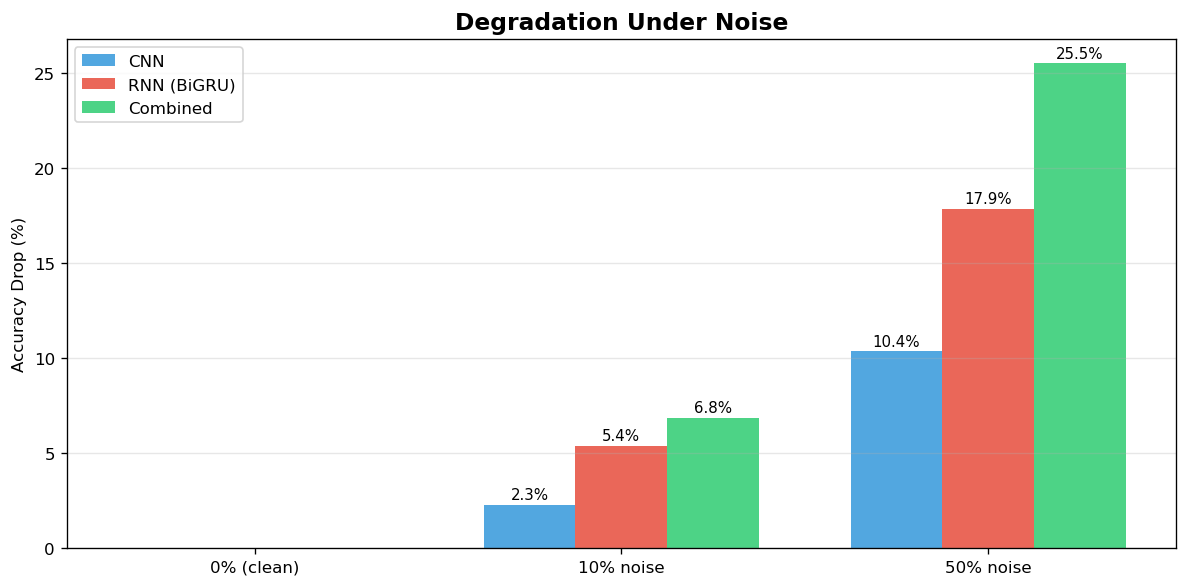

In [69]:
fig, ax = plt.subplots(figsize=(10,5))
x = np.arange(3); w = 0.25
for i,(mn,res) in enumerate(all_results.items()):
    clean = res[0.0]['accuracy']*100
    drops = [clean - res[nl]['accuracy']*100 for nl in noise_levels]
    bars = ax.bar(x+i*w, drops, w, label=mn, color=colors[mn], alpha=0.85)
    for b,d in zip(bars,drops):
        if d>0.5: ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f'{d:.1f}%', ha='center', fontsize=9)
ax.set_xticks(x+w); ax.set_xticklabels(['0% (clean)','10% noise','50% noise'])
ax.set_ylabel('Accuracy Drop (%)'); ax.set_title('Degradation Under Noise', fontsize=14, fontweight='bold')
ax.legend(); ax.grid(axis='y',alpha=0.3)
plt.tight_layout(); plt.show()

## 14. Confusion Matrices

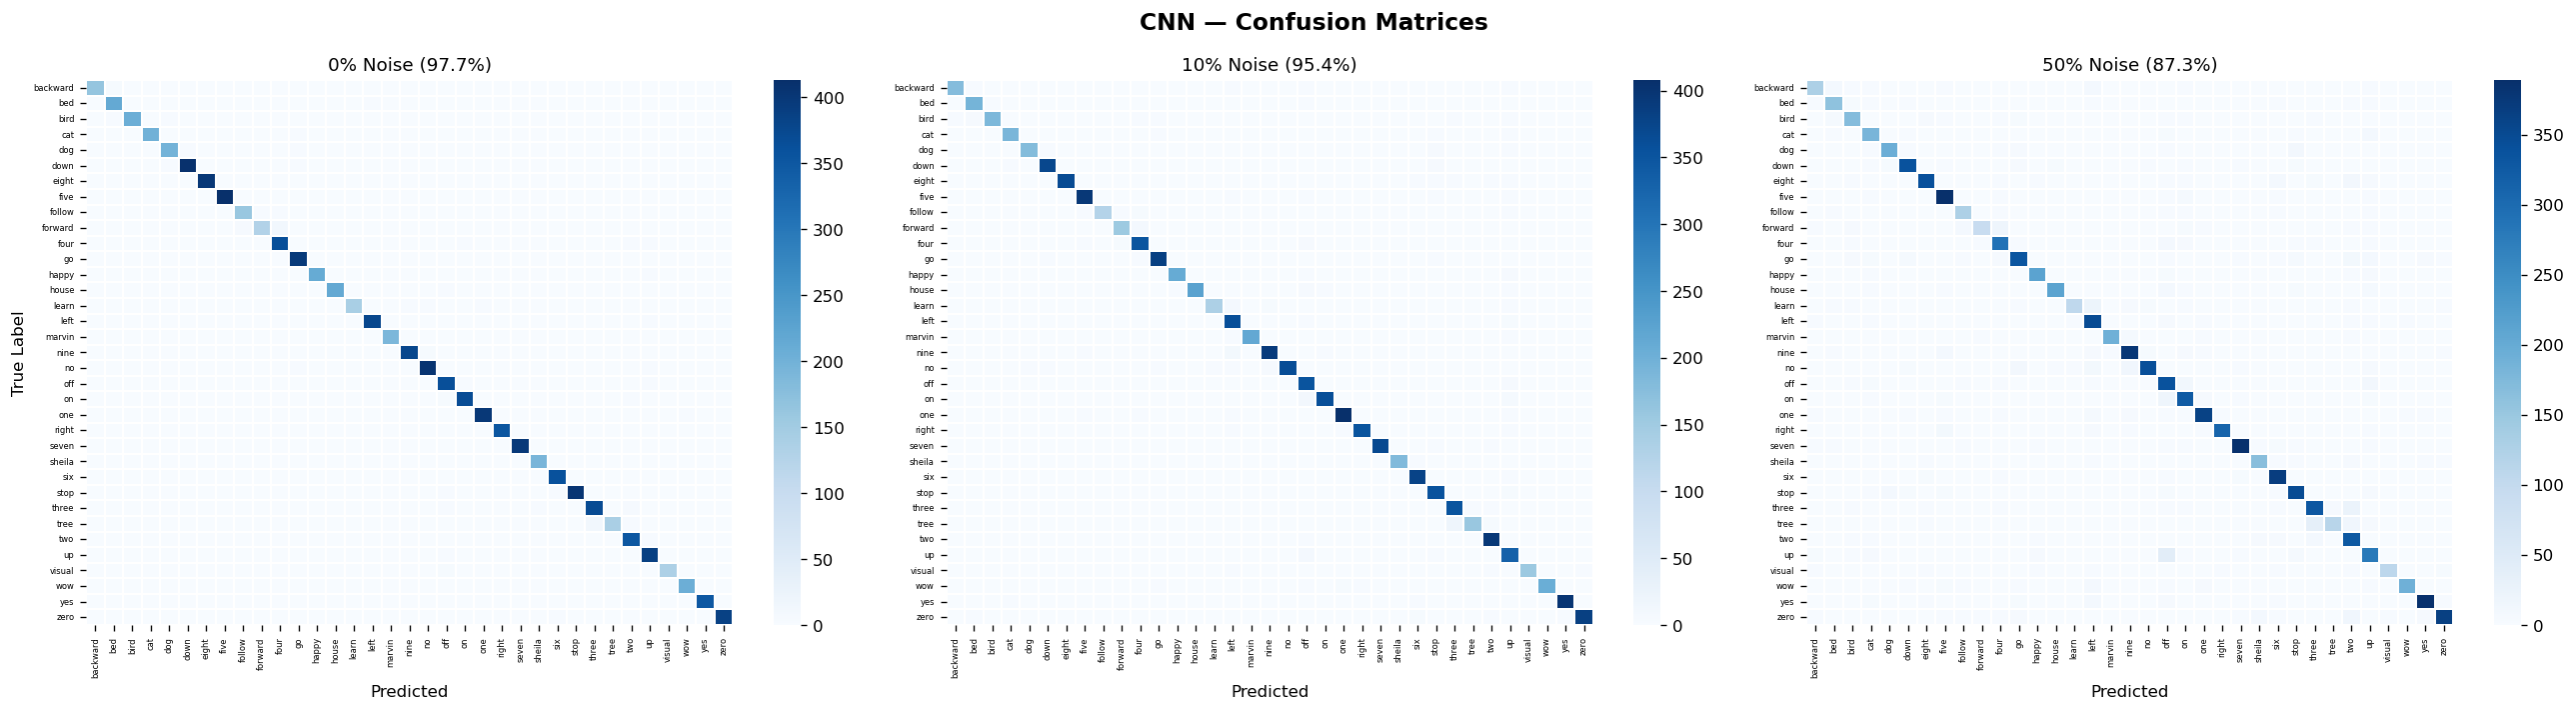

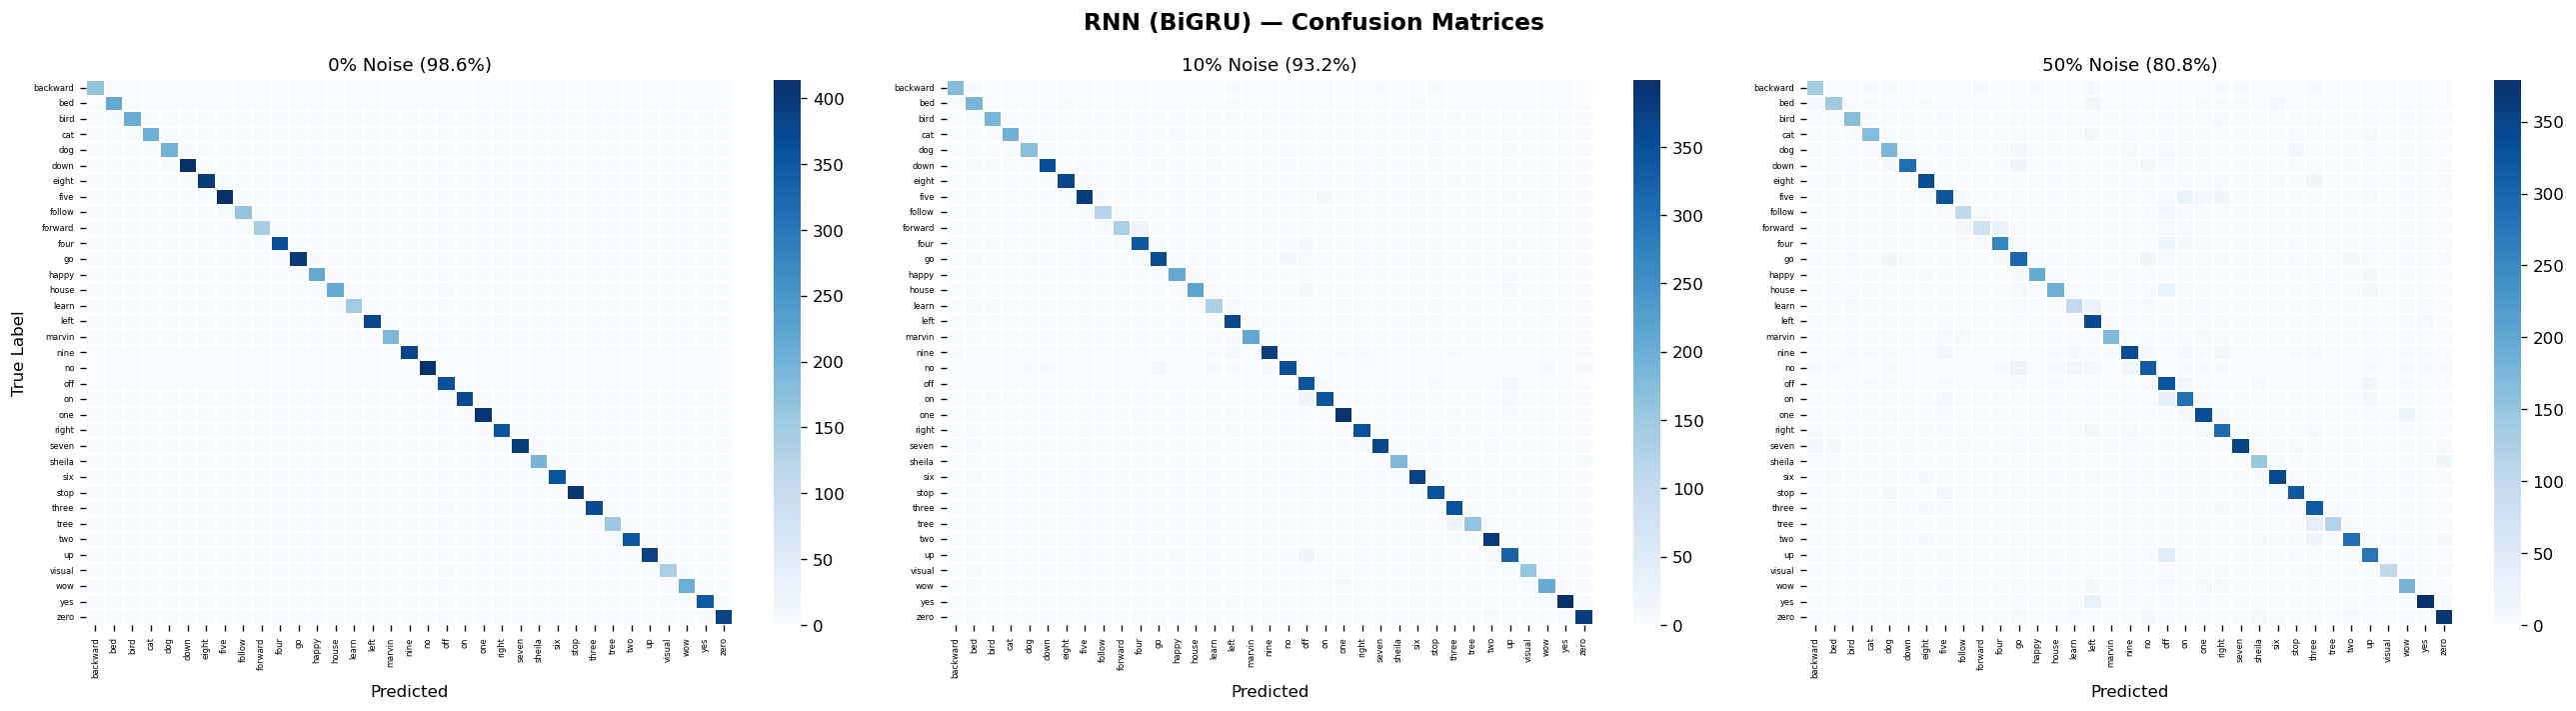

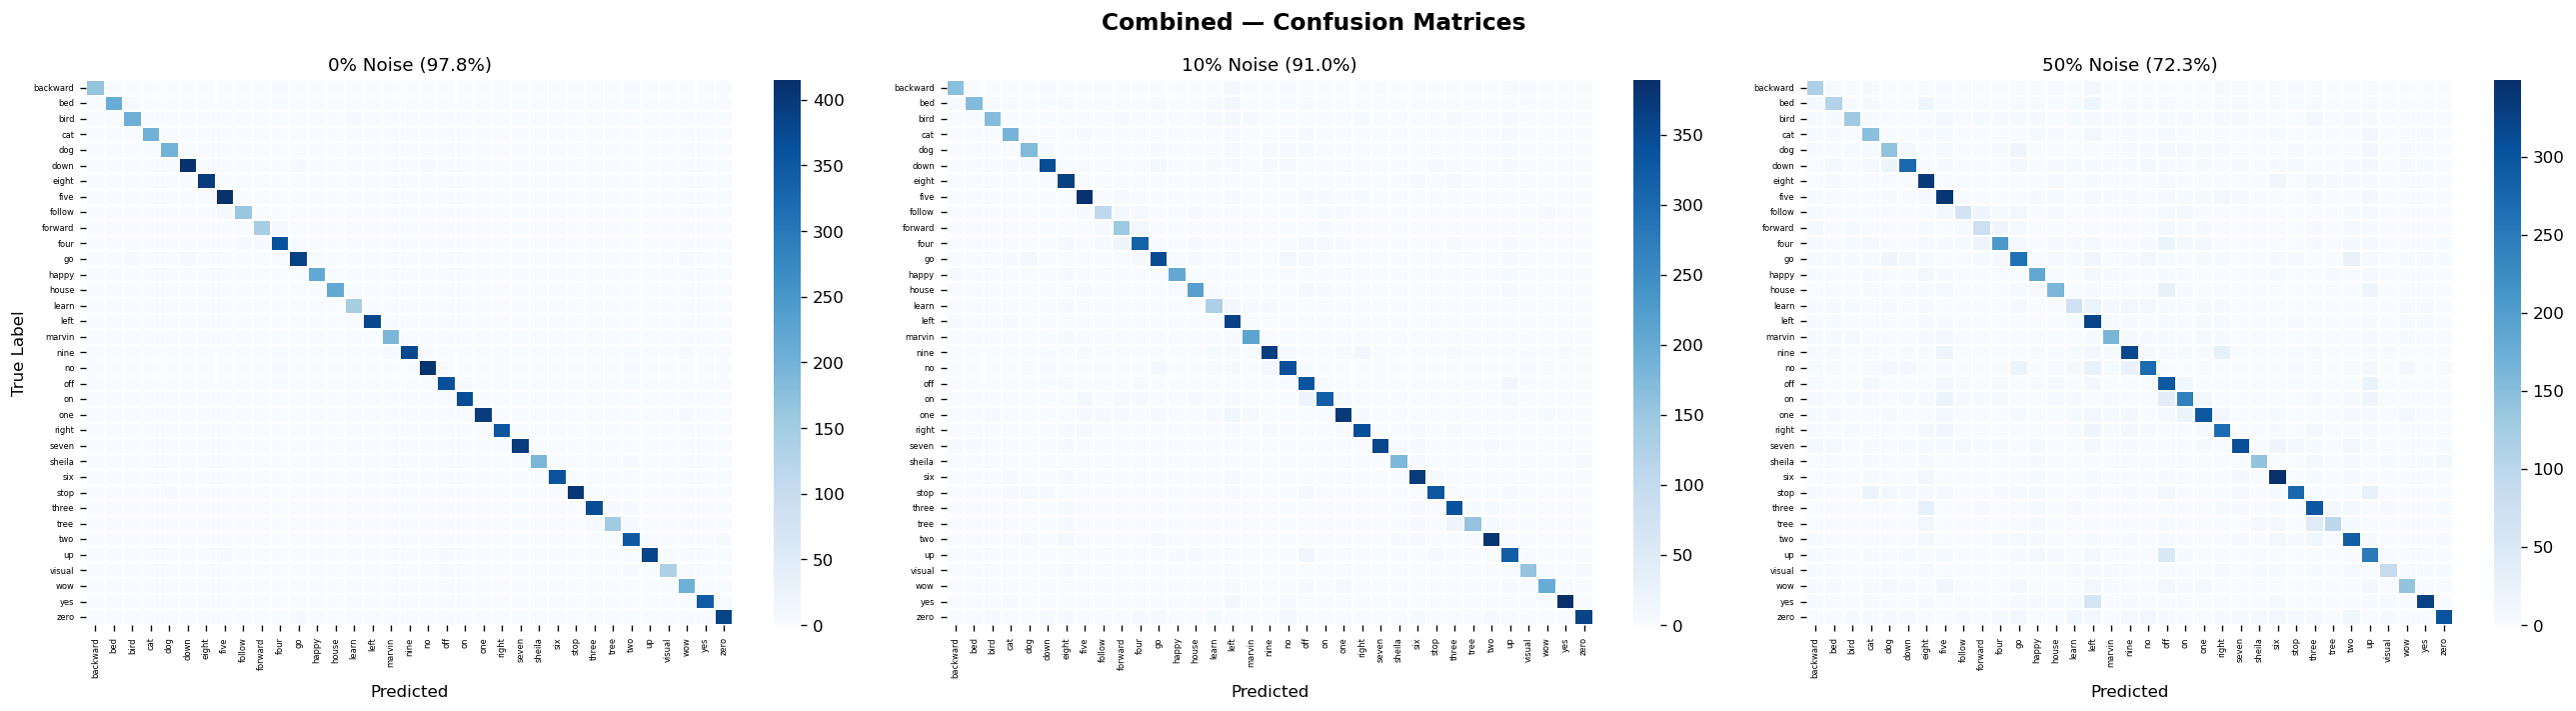

In [70]:
for mn, res in all_results.items():
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    for i, nl in enumerate(noise_levels):
        m = res[nl]; acc = m['accuracy']*100
        cm = confusion_matrix(m['y_true'], m['y_pred'])
        sns.heatmap(cm, cmap='Blues', ax=axes[i], linewidths=0.2, xticklabels=LABELS, yticklabels=LABELS)
        axes[i].set_title(f'{int(nl*100)}% Noise ({acc:.1f}%)', fontsize=11)
        axes[i].set_xlabel('Predicted')
        axes[i].tick_params(axis='x', labelrotation=90, labelsize=5)
        axes[i].tick_params(axis='y', labelrotation=0, labelsize=5)
    axes[0].set_ylabel('True Label')
    plt.suptitle(f'{mn} — Confusion Matrices', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()

## 15. Which Commands Are Most / Least Robust?

In [72]:
for mn, res in all_results.items():
    cm_c = confusion_matrix(res[0.0]['y_true'], res[0.0]['y_pred'])
    cm_n = confusion_matrix(res[0.5]['y_true'], res[0.5]['y_pred'])
    acc_c = cm_c.diagonal()/cm_c.sum(axis=1)
    acc_n = cm_n.diagonal()/cm_n.sum(axis=1)
    drops = acc_c - acc_n
    top5 = np.argsort(drops)[:5]; bot5 = np.argsort(drops)[-5:][::-1]
    print(f'\n{mn}')
    print(f'  Most robust (smallest drop):')
    for j in top5: print(f'    "{LABELS[j]}": {acc_c[j]*100:.1f}% → {acc_n[j]*100:.1f}% ({drops[j]*100:+.1f}%)')
    print(f'  Least robust (biggest drop):')
    for j in bot5: print(f'    "{LABELS[j]}": {acc_c[j]*100:.1f}% → {acc_n[j]*100:.1f}% ({drops[j]*100:+.1f}%)')


CNN
  Most robust (smallest drop):
    "five": 98.8% → 94.4% (+4.4%)
    "left": 97.4% → 92.8% (+4.6%)
    "six": 99.2% → 94.4% (+4.8%)
    "happy": 95.9% → 91.0% (+4.9%)
    "seven": 99.2% → 92.3% (+6.9%)
  Least robust (biggest drop):
    "learn": 93.4% → 65.8% (+27.5%)
    "forward": 85.5% → 64.8% (+20.7%)
    "up": 99.2% → 78.8% (+20.4%)
    "tree": 85.8% → 65.5% (+20.3%)
    "backward": 96.5% → 77.2% (+19.2%)

RNN (BiGRU)
  Most robust (smallest drop):
    "left": 98.4% → 90.9% (+7.5%)
    "yes": 98.9% → 89.6% (+9.3%)
    "eight": 99.3% → 88.3% (+11.0%)
    "six": 98.9% → 87.2% (+11.7%)
    "zero": 98.5% → 86.0% (+12.4%)
  Least robust (biggest drop):
    "forward": 94.1% → 51.7% (+42.4%)
    "learn": 99.3% → 61.5% (+37.8%)
    "tree": 96.9% → 67.8% (+29.1%)
    "follow": 97.1% → 68.2% (+28.8%)
    "go": 98.3% → 73.8% (+24.5%)

Combined
  Most robust (smallest drop):
    "six": 99.2% → 89.3% (+9.9%)
    "eight": 98.8% → 87.2% (+11.5%)
    "left": 98.2% → 86.1% (+12.1%)
    "five"

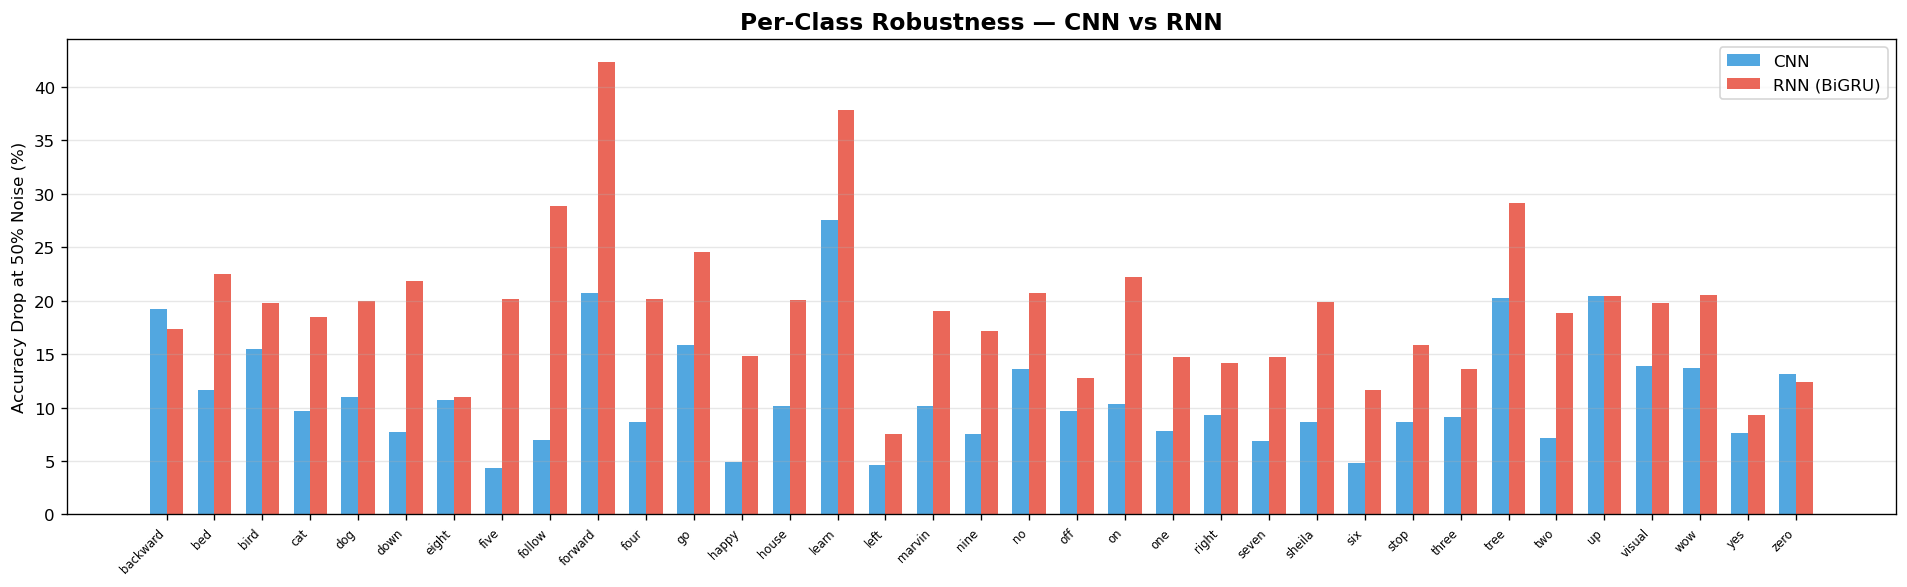

In [73]:
fig, ax = plt.subplots(figsize=(16,5))
x = np.arange(len(LABELS)); w = 0.35
for i, mn in enumerate(['CNN','RNN (BiGRU)']):
    cm_c = confusion_matrix(all_results[mn][0.0]['y_true'], all_results[mn][0.0]['y_pred'])
    cm_n = confusion_matrix(all_results[mn][0.5]['y_true'], all_results[mn][0.5]['y_pred'])
    drops = (cm_c.diagonal()/cm_c.sum(axis=1) - cm_n.diagonal()/cm_n.sum(axis=1))*100
    ax.bar(x+(i-0.5)*w, drops, w, label=mn, color=colors[mn], alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(LABELS, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Accuracy Drop at 50% Noise (%)')
ax.set_title('Per-Class Robustness — CNN vs RNN', fontsize=14, fontweight='bold')
ax.legend(); ax.grid(axis='y',alpha=0.3)
plt.tight_layout(); plt.show()

## 16. Analysis & Discussion

### 1) Which architecture performs better at each noise level?

| Model | 0% noise (clean) | 10% noise | 50% noise |
|------|------------------|-----------|-----------|
| CNN | 97.7% | **95.4%** | **87.3%** |
| RNN (BiGRU) | **98.6%** | 93.2% | 80.8% |
| CRNN (CNN + LSTM) | 97.8% | 91.0% | 72.3% |

At **0% noise**, the **RNN achieves the highest accuracy**, slightly outperforming both the CNN and the CRNN. This suggests that modelling the spectrogram as a sequence of time frames captures temporal speech patterns effectively when the signal is clean.

At **10% noise**, the **CNN becomes the best-performing model**, while the RNN and CRNN show larger drops in accuracy. This indicates that convolutional filters extract local time–frequency features that remain relatively stable under moderate background noise.

At **50% noise**, the **CNN clearly performs best**, while the RNN and CRNN show much larger performance degradation. This indicates that convolution-based representations are more robust under strong noise interference.

Overall, the results show a clear pattern: **RNN performs best on clean speech, while CNN provides the strongest robustness as noise increases.**


### 2) How does performance degrade as noise increases?

| Model | 0% noise | 10% noise | 50% noise | Total drop (0 → 50%) |
|------|----------|-----------|-----------|----------------------|
| CNN | 97.7% | 95.4% | 87.3% | **−10.4%** |
| RNN (BiGRU) | 98.6% | 93.2% | 80.8% | −17.8% |
| CRNN (CNN + LSTM) | 97.8% | 91.0% | 72.3% | −25.5% |

All three models show a gradual reduction in performance as noise increases, but the rate of degradation differs.

From **0% to 10% noise**, the drop is relatively small. Accuracy decreases by **2.3% for the CNN**, **5.4% for the RNN**, and **6.8% for the CRNN**, indicating that moderate background noise has only a limited effect on recognition accuracy.

From **10% to 50% noise**, the degradation becomes much larger. Accuracy decreases by **8.1% for the CNN**, **12.4% for the RNN**, and **18.7% for the CRNN**. This shows that the CNN remains the most stable model under stronger noise interference.

The loss values follow the same pattern, increasing steadily as noise levels rise. The largest increase is observed for the **CRNN**, indicating that its predictions become less stable under heavy noise.


### 3) What are the computational trade-offs between the approaches?

| Model | Parameters | Architecture | Training characteristics | Convergence | Gradient clipping |
|------|------------|--------------|--------------------------|-------------|-------------------|
| CNN | 549,769 | 2D convolutional network | Faster per epoch due to parallel convolution operations | ~epoch 6 to reach 90%+ validation accuracy | max_norm = 5.0 |
| RNN (BiGRU) | 568,131 | Bidirectional GRU network | Slower per epoch due to sequential GRU processing | ~epoch 3 to reach 90%+ validation accuracy | max_norm = 5.0 |
| CRNN (CNN + LSTM) | 454,319 | CNN feature extractor + LSTM | Moderate training speed with the lowest parameter count | ~epoch 4 to reach 90%+ validation accuracy | max_norm = 5.0 |

The CNN is computationally efficient per epoch because convolution operations run in parallel across the full spectrogram. This makes convolutional models well suited for large-scale audio processing where throughput matters.

The RNN processes the spectrogram sequentially using bidirectional GRU layers. Each epoch is slower due to step-by-step computation, but the model converges faster in terms of epochs, reaching strong validation accuracy earlier during training.

The CRNN combines convolutional feature extraction with recurrent temporal modelling while using the fewest parameters among the three architectures. Both parallel and sequential processing are present, but neither operates at full capacity at this parameter budget, which may contribute to the reduced noise resilience observed under heavy interference.

All three models use gradient clipping (`max_norm = 5.0`). While this is a standard precaution for CNNs, it is particularly important for recurrent architectures where sequential backpropagation through time can cause exploding gradients.


### 4) Which types of commands are most or least robust to noise?

Commands with **clear and distinctive acoustic patterns** remain more stable as noise increases, while **longer or phonetically similar commands** show larger performance drops.

Examples from the results include:

**Most robust commands:**
- *five*: 98.8% → 94.4% (CNN)
- *left*: 97.4% → 92.8% (CNN)
- *six*: 99.2% → 94.4% (CNN)
- *eight*: 99.3% → 88.3% (RNN)

These commands contain strong and distinctive spectral patterns that remain detectable even when background noise is present.

**Least robust commands:**
- *learn*: 93.4% → 65.8% (CNN), 99.3% → 61.5% (RNN), 95.4% → 44.1% (CRNN)
- *forward*: 94.1% → 51.7% (RNN), 94.7% → 51.0% (CRNN)
- *follow*: 94.2% → 44.6% (CRNN)
- *tree*: 96.9% → 67.8% (RNN)

These commands tend to be longer or phonetically similar to other words, which makes them more vulnerable when noise masks subtle frequency differences.


### 5) Which model performs best at very high noise levels?

At **50% noise**, the models perform as follows:

- **CNN:** 87.3%
- **RNN (BiGRU):** 80.8%
- **CRNN (CNN + LSTM):** 72.3%

**CNN** clearly performs best under very high noise conditions, maintaining the highest accuracy and the smallest overall degradation.


### 6) What level of noise is too high for reliable classification?

At **10% noise**, all models remain above **91% accuracy**, which indicates that mild background interference does not significantly affect recognition.

At **50% noise**, performance begins to separate more clearly. The **CNN and RNN remain above 80%**, but the **CRNN falls to 72.3%**, below the **75% reliability threshold**.

This suggests that around **50% noise** represents the practical limit for reliable classification in this setup.

---

## 17. Conclusion

This study evaluates which neural architecture maintains the most reliable performance as audio conditions degrade.

Three models - a CNN, an RNN (BiGRU), and a CRNN (CNN+LSTM) - were trained on the Google Speech Commands dataset and evaluated under clean, mildly noisy, and heavily noisy conditions.

All three architectures comfortably exceeded the **75% minimum accuracy requirement on clean data**, confirming that mel-spectrogram representations contain sufficient information for reliable **35-class speech command recognition** even with relatively modest model sizes (roughly **450K–570K parameters**).

### RNN (BiGRU)

The RNN model proved the **highest accuracy on clean data**. This reflects the strength of recurrent architectures in modelling temporal structure within speech. By analysing the spectrogram as a sequence of time frames, the bidirectional GRU can capture detailed temporal dynamics across the full one-second audio signal. However, this strength becomes a weakness when noise increases. When background noise disrupts the temporal patterns in the signal, the RNN’s performance degrades more noticeably than the CNN.


### CNN

The CNN model achieved to be the **most robust architecture under noisy conditions**. Convolutional layers detect localised time–frequency patterns within the spectrogram, and these compact patterns remain relatively stable even when parts of the signal are corrupted by noise. As noise increases, the CNN’s accuracy declines more slowly than the other models. This behaviour suggests that convolutional feature extraction produces representations that are naturally more resistant to spectral interference, making CNNs particularly suitable for real-world deployments where background noise is unavoidable.


### CRNN / Combined Model (CNN + LSTM)

The CRNN model introduces both spatial and temporal modelling by pairing a CNN feature extractor with an LSTM sequence model. Interestingly, it achieves accuracy comparable to the standalone architectures on clean data while using the **fewest parameters**. However, its performance declines more sharply as noise increases. This does not imply that hybrid architectures are inherently weaker. Instead, it suggests that **combining spatial and temporal processing may require greater model capacity** to maintain robustness.


### Practical Takeaways

The experiments reveal a clear trade-off between temporal modelling, noise robustness, and parameter efficiency.

- **CNN:** Best choice for deployments where background noise is common.
- **RNN (BiGRU):** Better when audio conditions are clean and controlled. 
- **CRNN (CNN + LSTM):** Efficient architecture that balances spatial and temporal modelling, but may require additional capacity to achieve strong robustness.

Future improvements could include **noise-augmented training**, **attention-based architectures**, or **pre-trained speech models such as Wav2Vec2**. These approaches could allow the models to learn more general audio representations and significantly improve performance across challenging acoustic environments.